# Análise Estatística e Semântica da Obra de Machado de Assis
Este projeto aplica técnicas de Text Mining aos romances de Machado de Assis para investigar a distribuição de frequência das palavras, verificar a Lei de Zipf e explorar padrões semânticos presentes nas obras.

## Introdução
A **Lei de Zipf** é uma lei empírica da linguística, que descreve como as palavras são distribuídas em um corpo de texto. Ela afirma que a frequência de qualquer palavra é inversamente proporcional ao seu rank na tabela de frequências. Essa relação pode ser modelada pela seguinte equação:

$$f(r) \propto \frac{C}{r^s}$$

Onde:
* **$f(r)$**: É a frequência da palavra que ocupa a posição $r$.
* **$C$**: É uma constante de normalização (a frequência da palavra mais comum).
* **$r$**: É o rank (posição) da palavra (1 para a mais comum, 2 para a segunda, etc).
* **$s$**: É o expoente de Zipf (o "coeficiente de inclinação"), que na linguagem natural costuma ser próximo de 1.

Quando aplicamos o logaritmo em ambos os lados da equação, a relação de potência se transforma em uma relação linear:

$$\log(f(r)) = \log(C) - s \cdot \log(r)$$

Isso explica por que, ao plotarmos os dados em um gráfico de escala logarítmica, esperamos encontrar uma **linha reta**.
Na análise empírica a ser realizada com os dados levantados através dos textos dos romances de Machado de Assis, será possível quantificar a diversidade do vocabulário, expresso pelo expoente de Zipf (s). Utilizaremos o modelo de **Regressão Linear** do `Scikit-Learn`. O objetivo é encontrar a inclinação s da reta no gráfico Log-Log, e assim verificar se: 
- \( $s \approx 1$ \): comportamento clássico da Lei de Zipf, com distribuição equilibrada das frequências.
- \( s > 1 \): a frequência das palavras decai mais rapidamente, indicando menor diversidade lexical e maior concentração em poucas palavras.
- \( s < 1 \): a frequência decai mais lentamente, indicando maior diversidade de vocabulário. 



**Machado de Assis** (1839–1908) é amplamente considerado um dos maiores escritores da literatura brasileira. Fundador da Academia Brasileira de Letras, sua obra é marcada pela profundidade psicológica, ironia refinada e análise crítica da sociedade do século XIX.
Para base desse estudo, serão considerados todos seus romances: 
- **Fase romântica**:
    - Ressurreição (1872);
    - A Mão e a Luva (1874);
    - Helena (1876);
    - Iaiá Garcia (1878).
- **Fase realista**:
    - Memórias Póstumas de Brás Cubas (1881);
    - Casa Velha (1885);
    - Quincas Borba (1891);
    - Dom Casmurro (1899);
    - Esaú e Jacó (1904);
    - Memorial de Aires (1908).
    
No contexto deste projeto, a obra de Machado de Assis oferece um material particularmente interessante para análise estatística e semântica, devido à sua diversidade vocabular e à densidade conceitual de seus romances. A investigação da frequência de palavras e da distribuição lexical permite observar padrões estruturais da linguagem, como aqueles descritos pela Lei de Zipf, ao mesmo tempo em que possibilita explorar aspectos temáticos e semânticos presentes em sua produção literária.

## Análise estatística
Tendo os romances em arquivos txt em pastas separadas pelas fases literárias:
'obras/romântica/...'
'obras/realista/...'
Primeiramente, importamos as bibliotecas e criamos as funções de pipeline de tratamentos dos dados dos arquivos txt e calculamos o s (expoente de Zipf) e R² (coeficiente de determinação):

In [11]:
import pandas as pd
from collections import Counter
import string
from sklearn.linear_model import LinearRegression
import numpy as np

def processar_obra(caminho_arquivo): 
    with open(caminho_arquivo, 'r', encoding='utf-8') as f:  # Leitura do arquivo
        texto = f.read().lower()
    pontuacao_estendida = string.punctuation + '—' + '“' + '”' +'–'  # Limpeza dos dados, retirada das pontuações
    texto_limpo = texto.translate(str.maketrans('', '', pontuacao_estendida))
    palavras = texto_limpo.split()
    contagem = Counter(palavras)   # Contagem e dataframe
    df = pd.DataFrame(contagem.items(), columns=['Palavra', 'Frequência'])
    df = df.sort_values(by='Frequência', ascending=False).reset_index(drop=True)
    
    y_log = np.log10(df['Frequência'].values)   #Cálculo da lei de Zipf com regressão linear
    rank = np.arange(1, len(y_log) + 1)
    X_log = np.log10(rank).reshape(-1, 1)
    modelo = LinearRegression()
    modelo.fit(X_log, y_log)   
    s = abs(modelo.coef_[0])   # Extraindo s e R²
    r2 = modelo.score(X_log, y_log)   
    
    return df, s, r2

In [12]:
df_brascubas, s_bras, r2_bras = processar_obra('obras/realista/Memórias Póstumas de Brás Cubas.txt')
print(f"Brás Cubas -> s: {s_bras:.2f} | R²: {r2_bras:.4f}")
print(df_brascubas.head(5))

Brás Cubas -> s: 0.92 | R²: 0.9537
  Palavra  Frequência
0       a        2522
1     que        2218
2      de        2129
3       e        2012
4       o        1773


Agora, criar a função para plotar os gráficos (um contendo a distribuição das 25 palavras mais frequentes e outro mostrando a reta da regressão linear): 

In [13]:
import matplotlib.pyplot as plt

def gerar_graficos(df, titulo_obra, s, r2):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(f'Análise de Obra: {titulo_obra}', fontsize=16, fontweight='bold')
    
    top_25 = df.head(25)   # lado esquerdo = palavras mais frequentes
    cores = plt.cm.plasma(np.linspace(0, 1, 25))
    ax1.bar(top_25['Palavra'], top_25['Frequência'], color=cores)
    ax1.set_title('Top 25 Palavras (Bruto)')
    ax1.tick_params(axis='x', labelrotation=45)
    ax1.grid(axis='y', alpha=0.3)

    freq = df['Frequência'].values # Lado direito = Lei de Zipf (Log-Log)
    rank = np.arange(1, len(freq) + 1)
    
    frequencia_teorica = freq[0] / rank  # Cálculo das retas
    y_log_pred = np.log10(freq[0]) - s * np.log10(rank)
    reta_regressao = 10**y_log_pred

    ax2.plot(rank, freq, label='Empírico', color='blue')
    ax2.plot(rank, frequencia_teorica, label='Teórica (s=1)', color='red', linestyle='--')
    ax2.plot(rank, reta_regressao, label=f'Regressão (s={s:.2f})', color='green')
    
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.set_title(f'Lei de Zipf ($R^2$ = {r2:.4f})')
    ax2.legend()
    ax2.grid(True, which="both", alpha=0.2)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta para não sobrepor o título principal
    plt.show()
    pass
    

Loop para processar todas as obras, plotar seus gráficos e criar dataframes que agrupam obras por fases literárias (para posterior análise semântica) e um dataframe contendo todas obras.

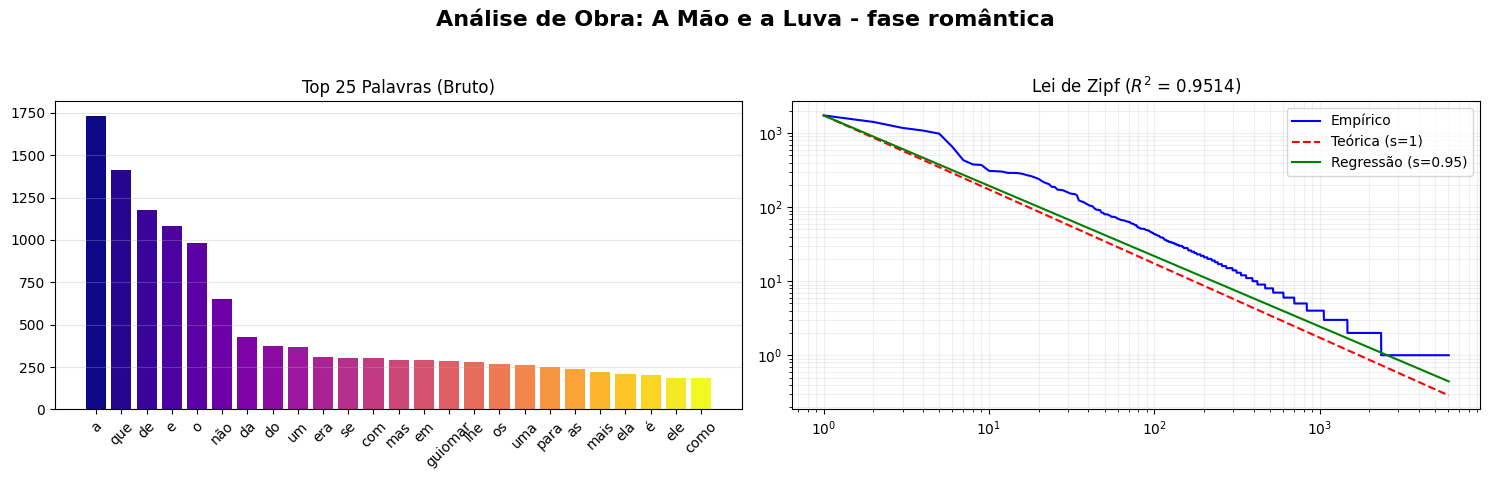

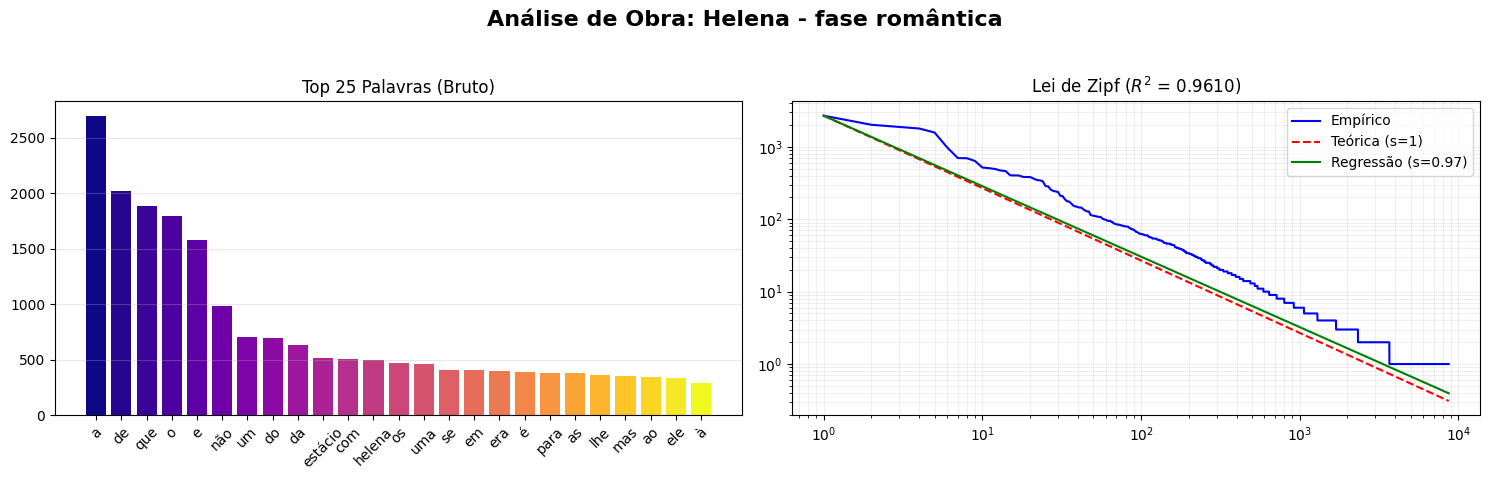

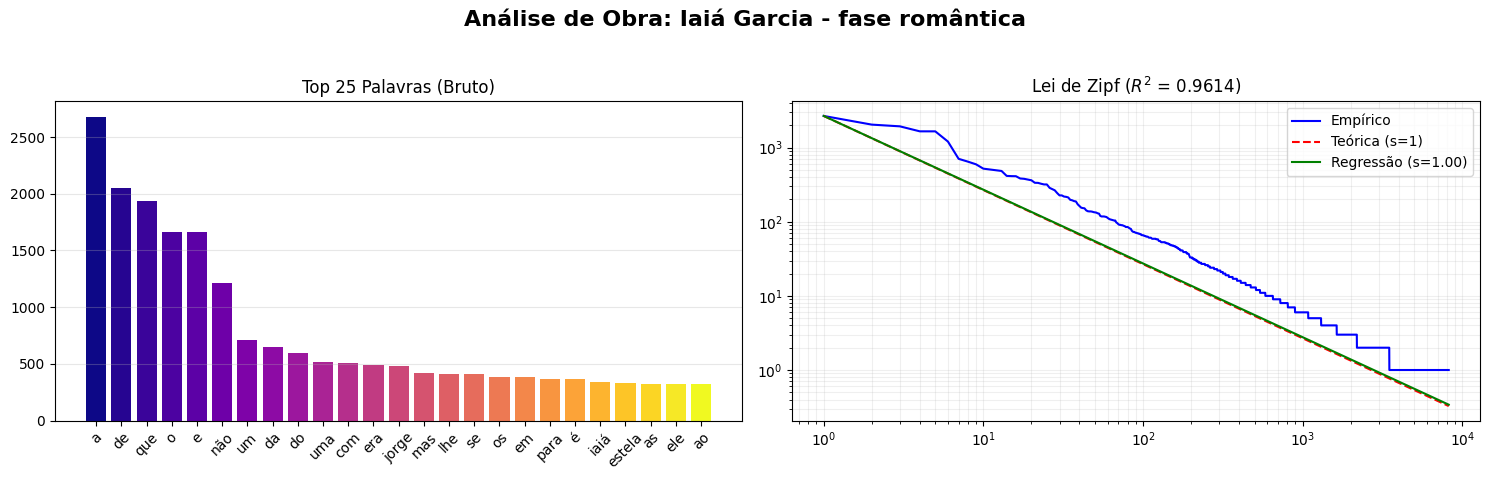

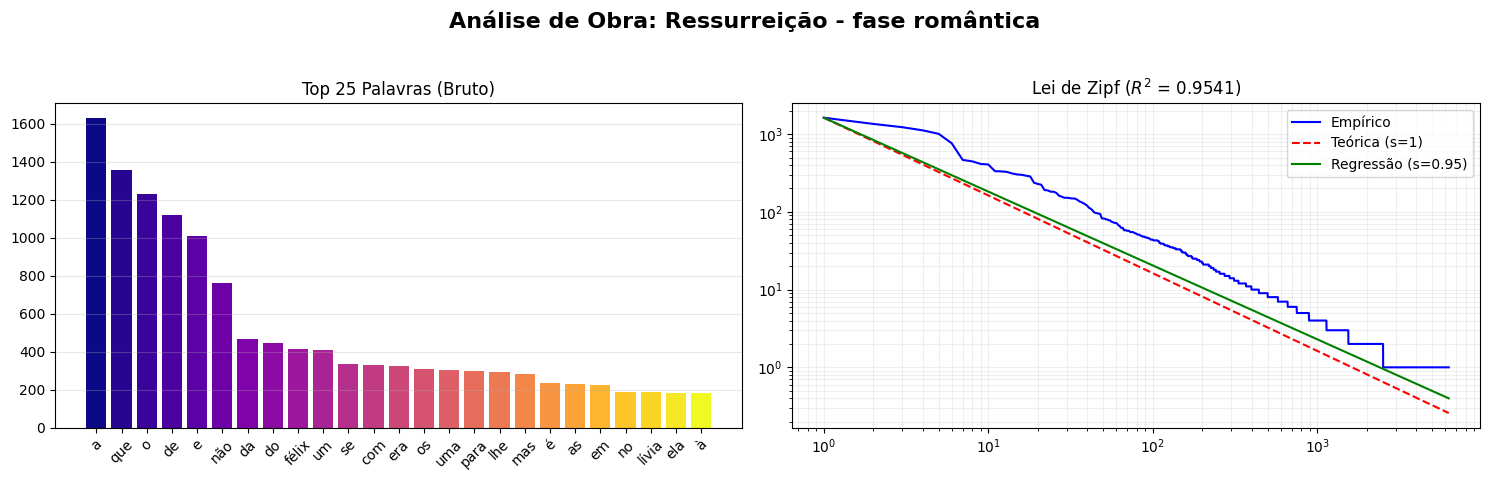

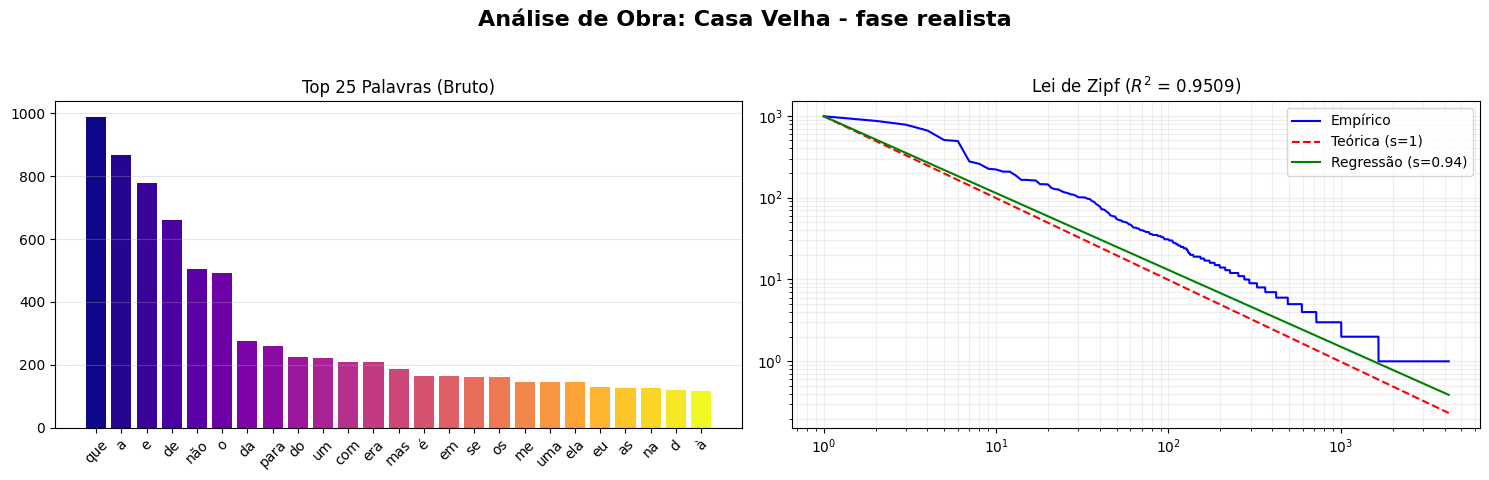

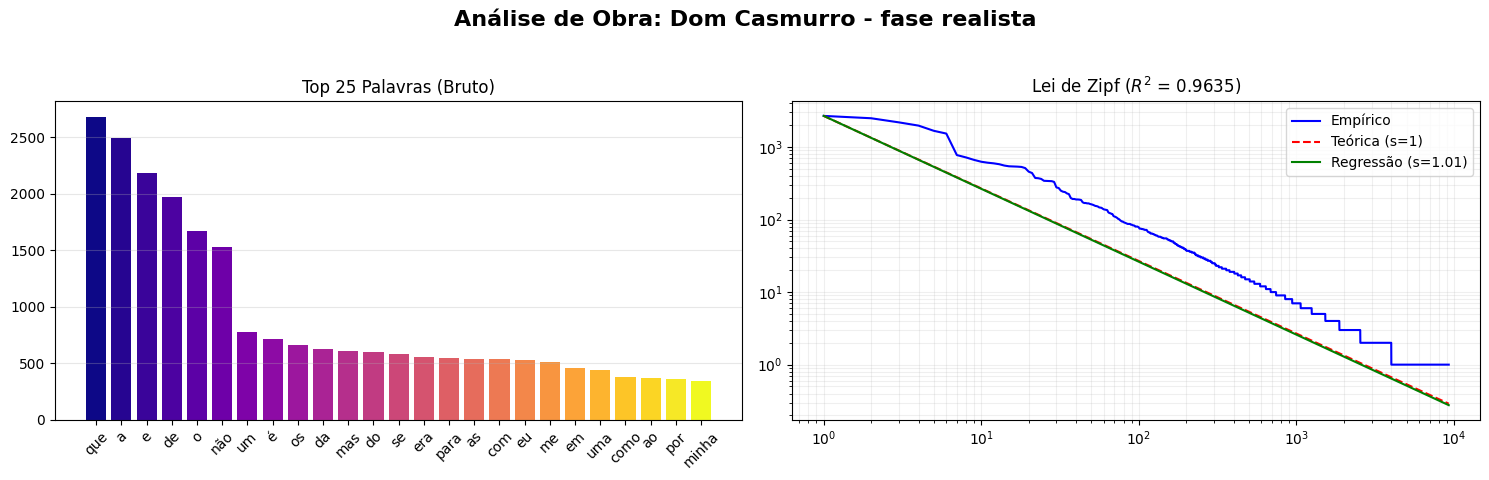

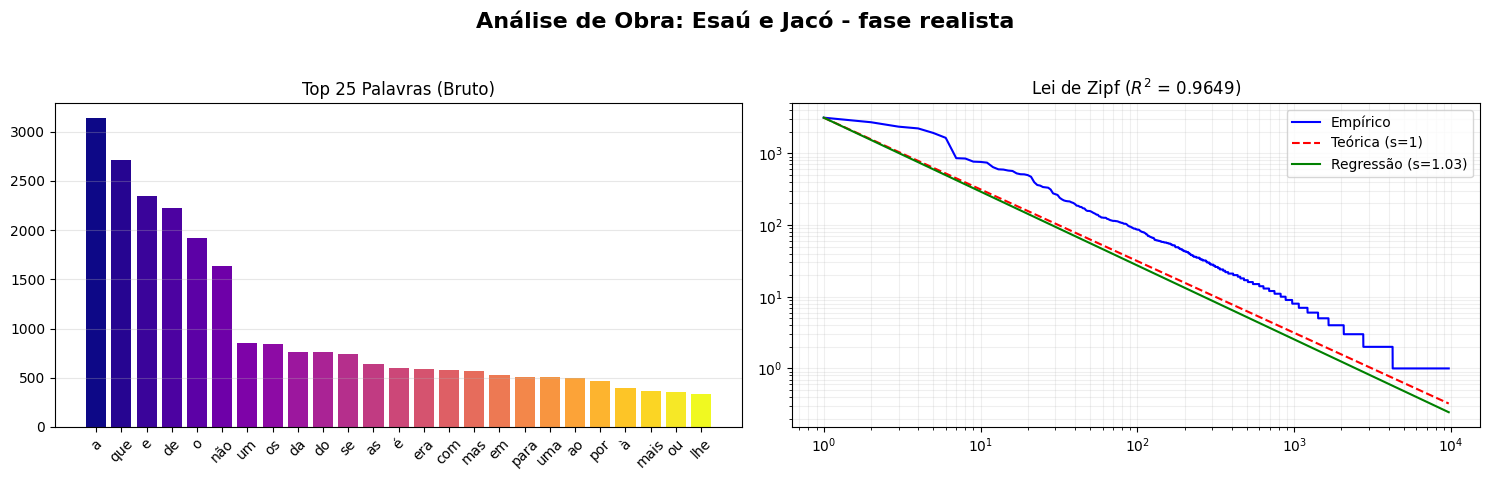

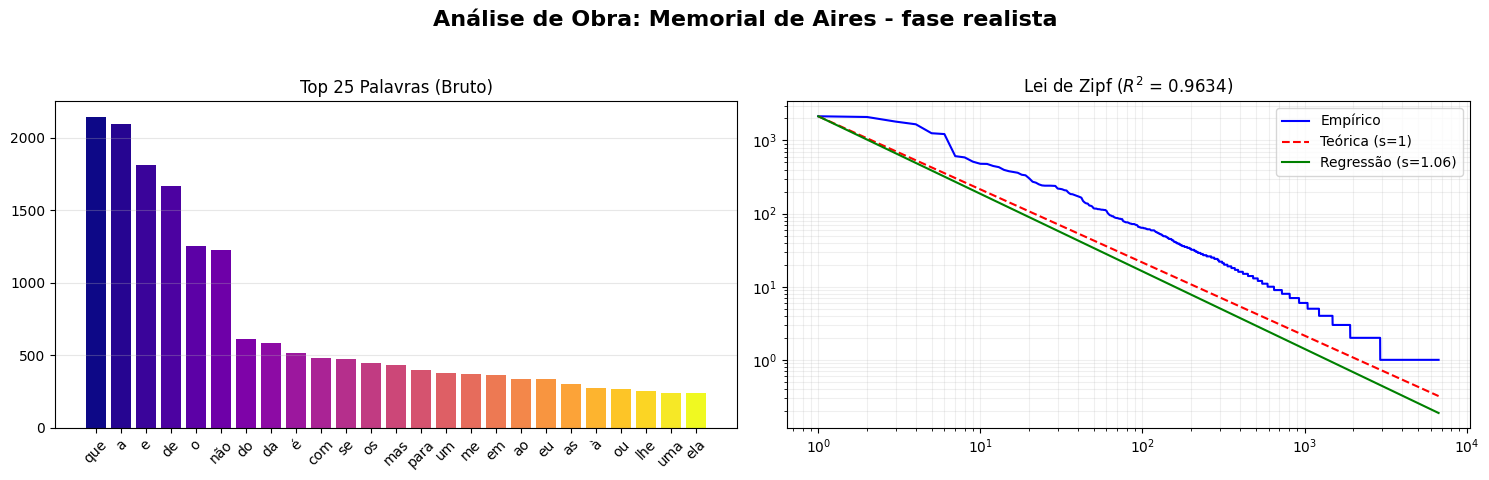

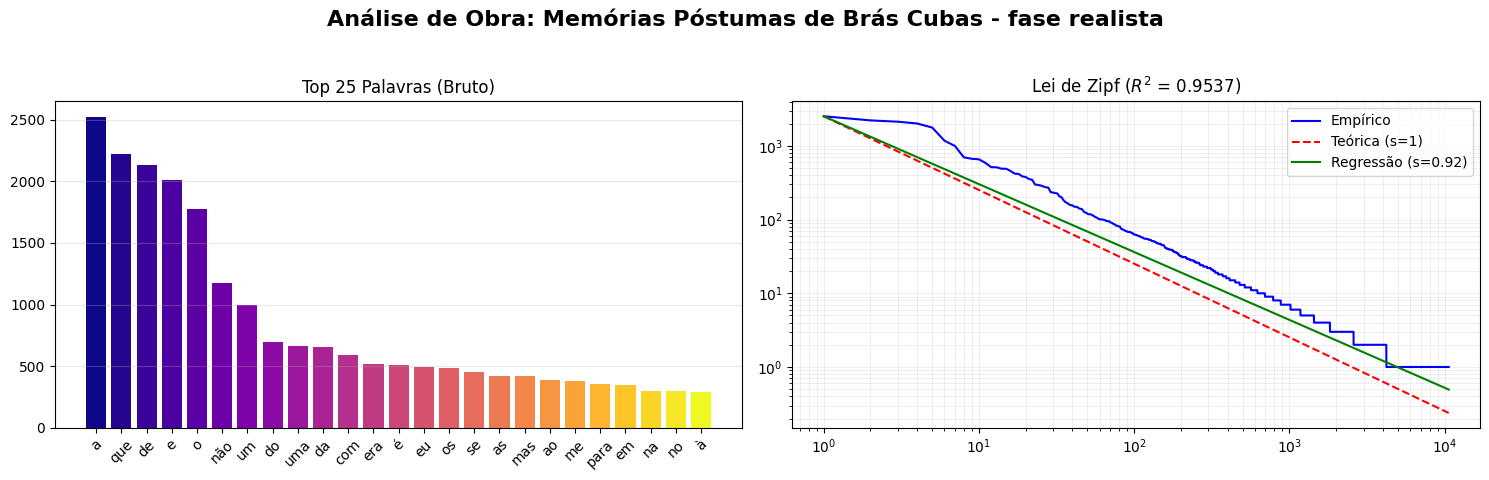

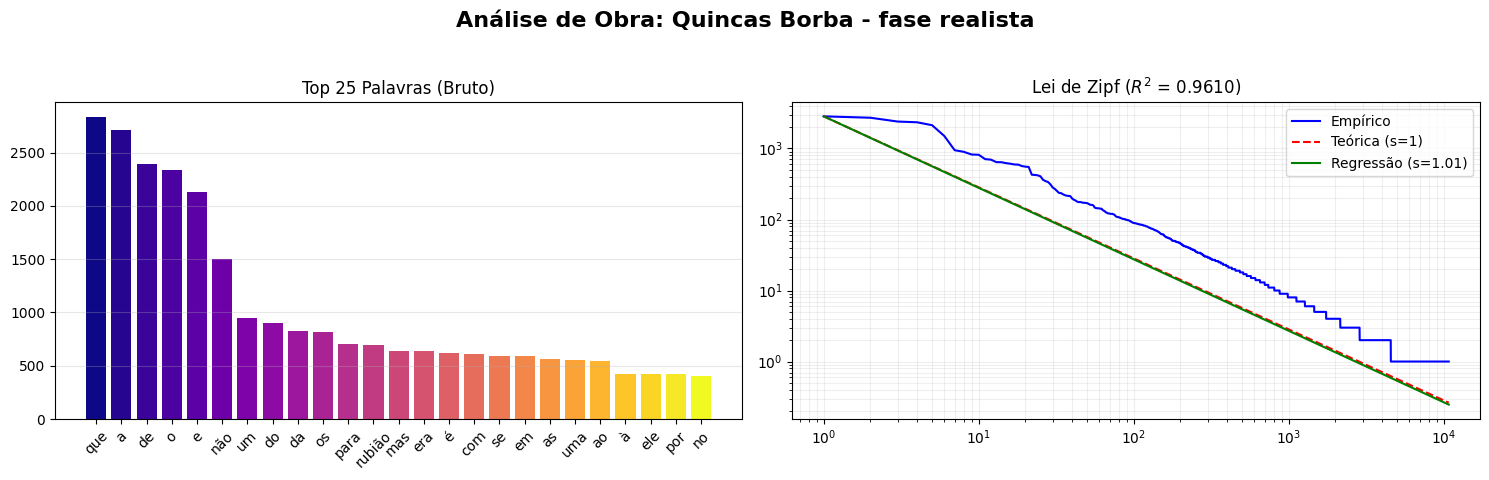

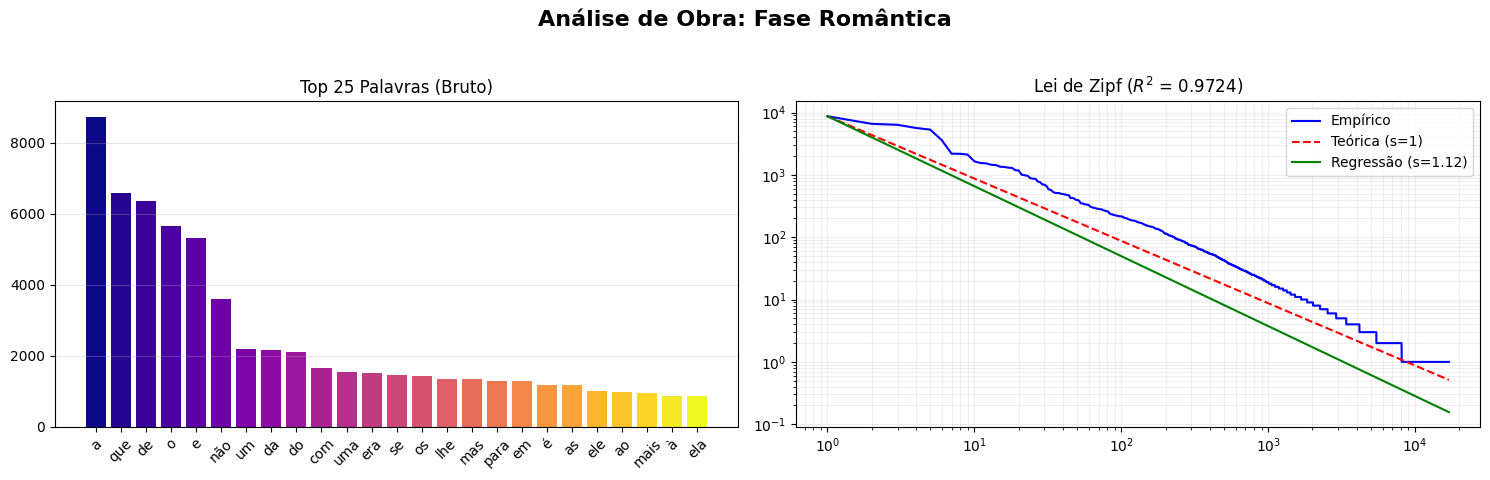

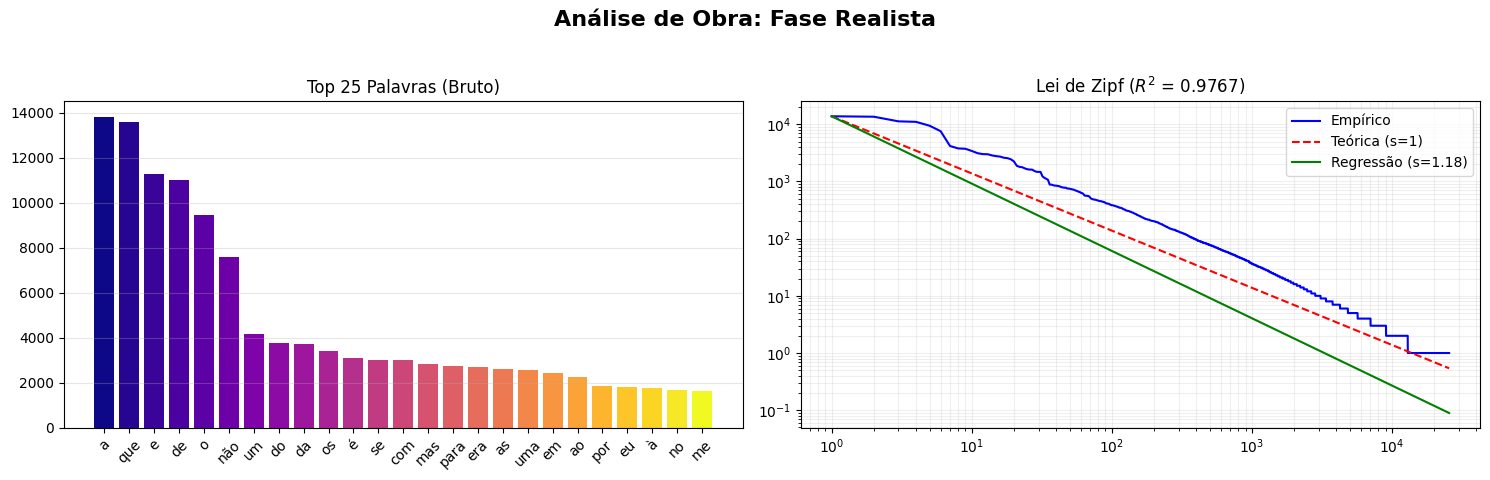

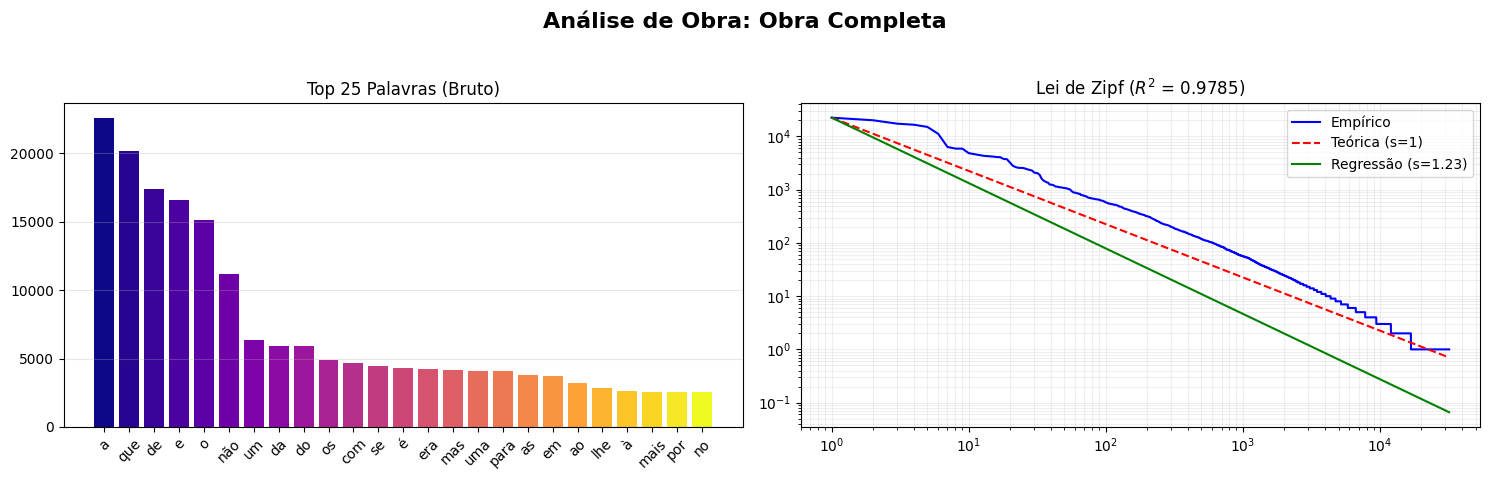

In [14]:
import os
import glob

categorias = ['romântica', 'realista']
resultados_por_fase = {'romântica': "", 'realista': ""}
todas_obras_texto = ""

for fase in categorias:
    arquivos = glob.glob(f'obras/{fase}/*.txt')
    
    for arq in arquivos:
        nome_obra = os.path.basename(arq).replace('.txt', '')
        df, s, r2 = processar_obra(arq)  # Processando e gerando gráfico individual
        gerar_graficos(df, f"{nome_obra} - fase {fase}", s, r2)
        
        with open(arq, 'r', encoding='utf-8') as f:
            conteudo = f.read()      # Acumulando para a fase e para o total
            resultados_por_fase[fase] += " " + conteudo
            todas_obras_texto += " " + conteudo

for fase, texto_acumulado in resultados_por_fase.items():
    if texto_acumulado.strip():    # Processar e gerar gráficos para as Fases
        nome_arq_fase = f"temp_fase_{fase}.txt"    # Cria um nome de arquivo para a fase
        with open(nome_arq_fase, 'w', encoding='utf-8') as f:  # Salva o texto acumulado no arquivo
            f.write(texto_acumulado)
        df_fase, s_fase, r2_fase = processar_obra(nome_arq_fase)
        gerar_graficos(df_fase, f"Fase {fase.capitalize()}", s_fase, r2_fase)

if todas_obras_texto.strip(): # Processar Obra Completa
    nome_arq_total = "temp_obra_completa.txt"
    with open(nome_arq_total, 'w', encoding='utf-8') as f:
        f.write(todas_obras_texto)
    df_total, s_total, r2_total = processar_obra(nome_arq_total)
    gerar_graficos(df_total, "Obra Completa", s_total, r2_total)

# Resultados
| Obra                          | Ano  | s    | R²     |
|------------------------------|------|------|--------|
| Ressurreição                 | 1872 | 0,95 | 0,9514 |
| A Mão e a Luva               | 1874 | 0,95 | 0,9514 |
| Helena                       | 1876 | 0,97 | 0,9610 |
| Iaiá Garcia                  | 1878 | 1,00 | 0,9614 |
| **Média da fase romântica**  | —    | 1,12 | 0,9724 |
| Memórias Póstumas de Brás Cubas      | 1881 | 0,92 | 0,9537 |
| Casa Velha                           | 1885 | 0,94 | 0,9509 |
| Quincas Borba                        | 1891 | 1,01 | 0,9610 |
| Dom Casmurro                         | 1899 | 1,01 | 0,9635 |
| Esaú e Jacó                          | 1904 | 1,03 | 0,9649 |
| Memorial de Aires                    | 1908 | 1,06 | 0,9634 |
| **Média da fase realista**           | —    | 1,18 | 0,9767 |
| **Todas as obras** | — | 1,23 | 0,9785 |

Esta etapa validou a aplicação da Lei de Zipf ($f(r) \propto 1/r^s$) nos dez romances de Machado de Assis, dividos entre suas fases literárias romântica e realista. A análise focou na relação entre a frequência das palavras e suas posições no ranking, e posterior cálculo do expoente s pela regressão linear.

**Análise do Coeficiente de determinação (R²):**
Em todas as obras individuais, o R² manteve-se consistentemente acima de 0,95, atingindo 0,9785 na análise da obra completa consolidada. Um R²>0,90 indica um ajuste dos dados extremamente adequado à reta modelo da regressão linear. Isso mostra que a distribuição de palavras na escrita de Machado segue essa estrutura matemática.

**Evolução do expoente s:** o expoente s (expoente de Zipf e inclinação da reta no gráfico log-log) reflete a diversidade do vocabulário do autor. Se olharmos para a lista de resultados, há uma tendência de crescimento do s conforme o tempo. Até 1885, o índice varia entre menor ou igual a 1,00, o que indica que o autor usa um vocabulário variado e distribuído de forma mais suave, o que pode ser um reflexo da característica do romantismo de descrições mais ricas, detalhadas e poéticas. Além disso, Memórias Póstumas de destaca com o menor s, podendo indicar o aspecto inovador e fragmentado da obra, com vários capítulos curtos, em que diversos assuntos da vida inteira do narrador são expostos com humor e ironia.

Nas suas demais obras posteriores, é notório o crescimento do expoente, chegando a 1,06 em Memorial de Aires, o que indica maior concentração de menos palavras. Esse fato pode indicar um maior foco narrativo e coesão nesses romances, isso faz certas palavras (ligadas aos temas centrais) se repetirem mais, como por exemplo, Dom Casmurro que gira muito em torno do ciúme de Bentinho por Capitu. Além também, da constante análise psicológica existente no realismo, o uso da repetição como recurso psicológico, em que ideias, dúvidas e obsessões são retomadas várias vezes.

Ao agrupar as obras em fases e unir todas, notamos a fase romântica com um índice menor (1,12), mostrando um vocabulário mais distribuído e a fase realista com o índice maior, com mais concentração de frequência em termos específicos e palavras funcionais (1,18). Por fim, o cálculo com todas as obras mostrou o s mais alto (1,23), isso se deve ao fato de que, ao juntar todos os livros, as "stopwords" (como "de", "que", "a", "o") acumulam muita frequência, mas a palavras de conteúdo temático específicas para cada livro ficam diluídas. Isso cria um topo da pirâmide muito mais alto e uma base (as palavras raras) que não cresce na mesma velocidade.

# Análise semântica
Criaremos uma função para criar o dataframe com a distribuição de frequências de palavras de cada obra, de cada fase e o agrupamento total. Depois, retiraremos as Stop Words (palavras de conexão, artigos, preposições, etc), que não possuem uma semântica intrínseca, através da biblioteca nltk. E por último, plotar um gráfico de barras com as palavras mais frequentes e outro com uma nuvem de palavras, da biblioteca wordcloud.

In [15]:
from nltk.corpus import stopwords

def processar_obra2(caminho_arquivo): 
    with open(caminho_arquivo, 'r', encoding='utf-8') as f:  # Leitura do arquivo
        texto = f.read().lower()
    pontuacao_estendida = string.punctuation + '—' + '“' + '”' +'–'  # Limpeza dos dados, retirada das pontuações
    texto_limpo = texto.translate(str.maketrans('', '', pontuacao_estendida))
    palavras = texto_limpo.split()
    
    stop_words_nltk = stopwords.words('portuguese')
    palavras_finais = [p for p in palavras if p not in stop_words_nltk and len(p) > 1] # Retira as stopwords
    contagem_auto = Counter(palavras_finais)
    df = pd.DataFrame(contagem_auto.items(), columns=['Palavra', 'Frequência']) # Cria o dataframe
    df = df.sort_values(by='Frequência', ascending=False).reset_index(drop=True)
    return df

from wordcloud import WordCloud

def gerar_graficos2(df, titulo_obra):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(f'Análise semântica de Obra: {titulo_obra}', fontsize=16, fontweight='bold')
    
    top_25 = df.head(25)   # lado esquerdo = palavras mais frequentes (sem stopwords)
    cores = plt.cm.rainbow_r(np.linspace(0, 1, 25))
    ax1.bar(top_25['Palavra'], top_25['Frequência'], color=cores)
    ax1.set_title('Top 25 Palavras (sem stopwords)')
    ax1.tick_params(axis='x', labelrotation=45)
    ax1.grid(axis='y', alpha=0.3)

    dicionario_freq = dict(zip(top_25['Palavra'], top_25['Frequência'])) # lado direito: nuvem de palavras
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(dicionario_freq)
    ax2.imshow(wordcloud, interpolation='bilinear')
    ax2.set_title('Nuvem de Palavras')
    ax2.axis('off')

    plt.tight_layout()
    plt.show()
    pass



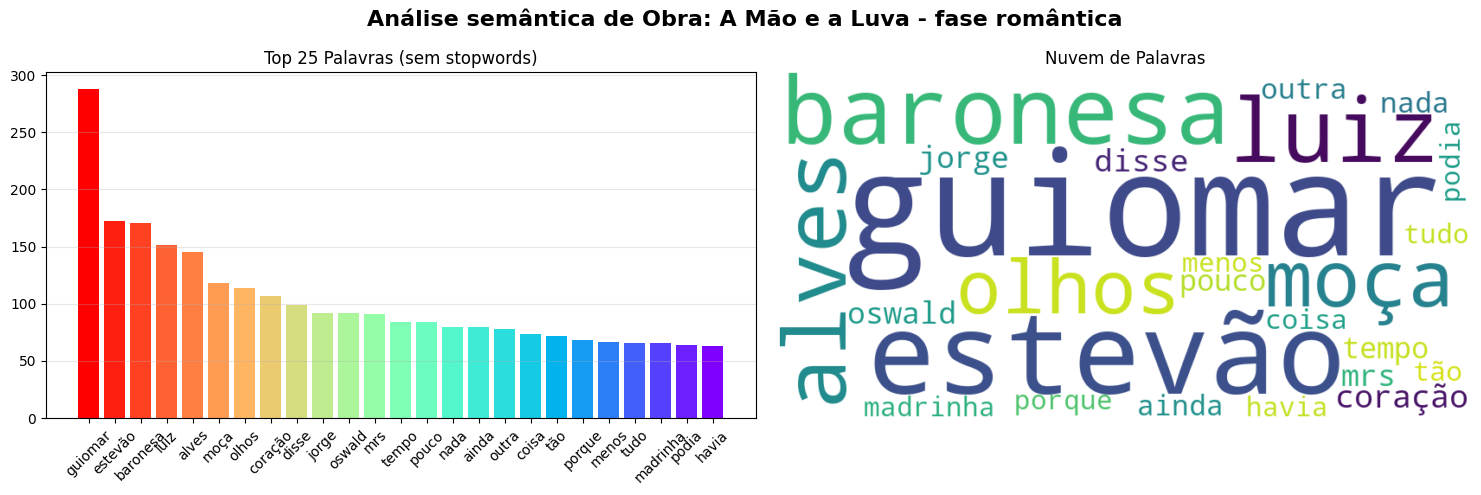

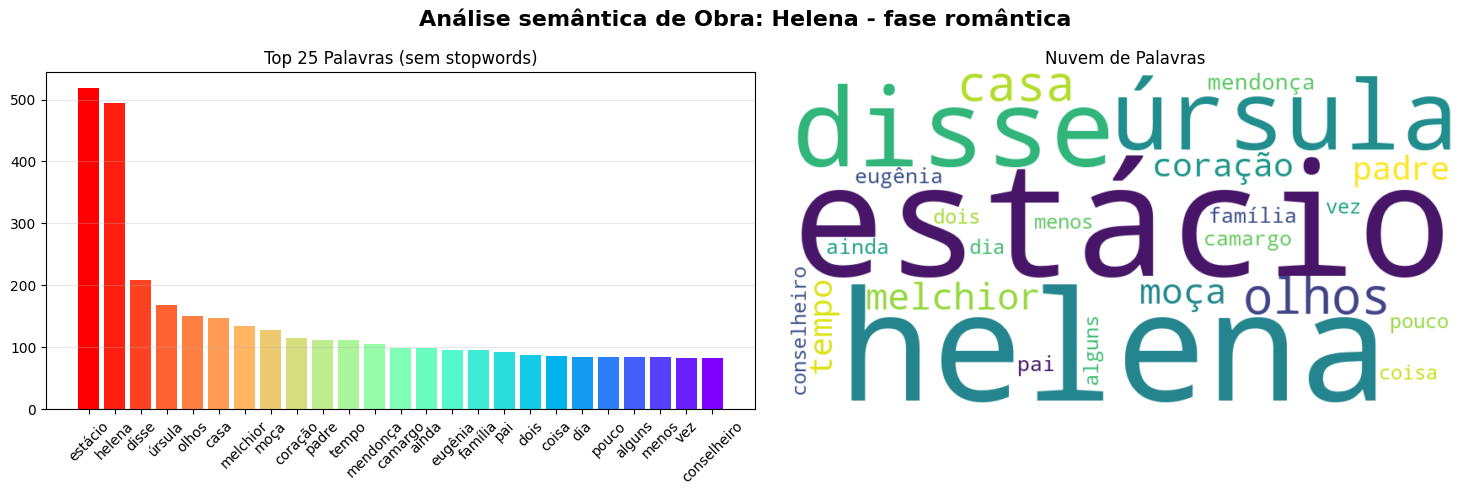

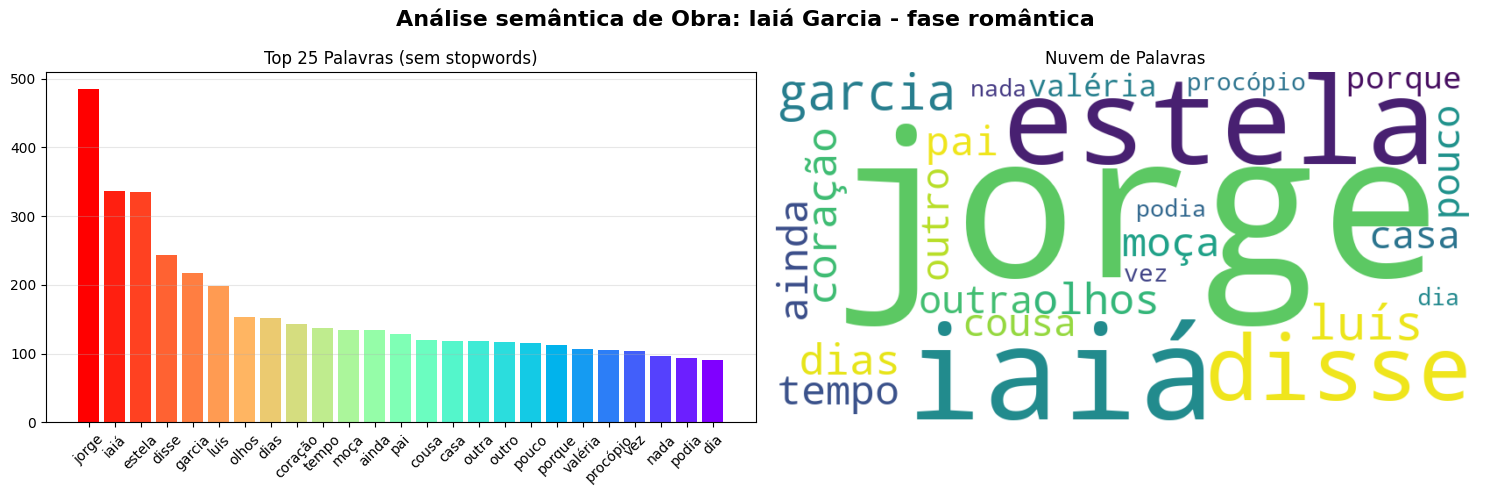

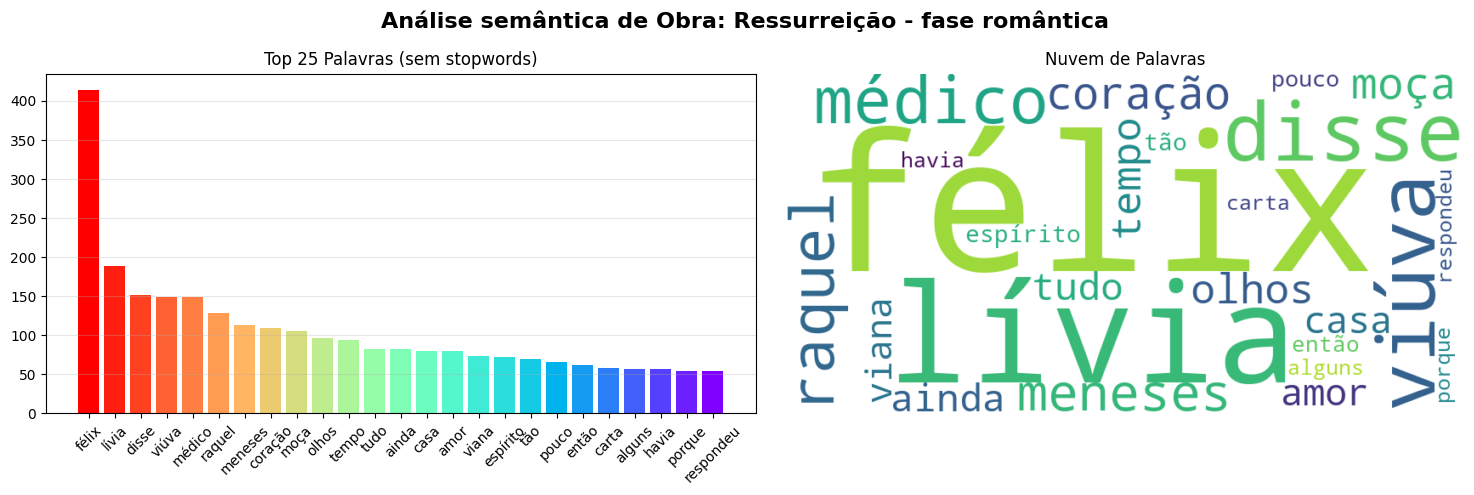

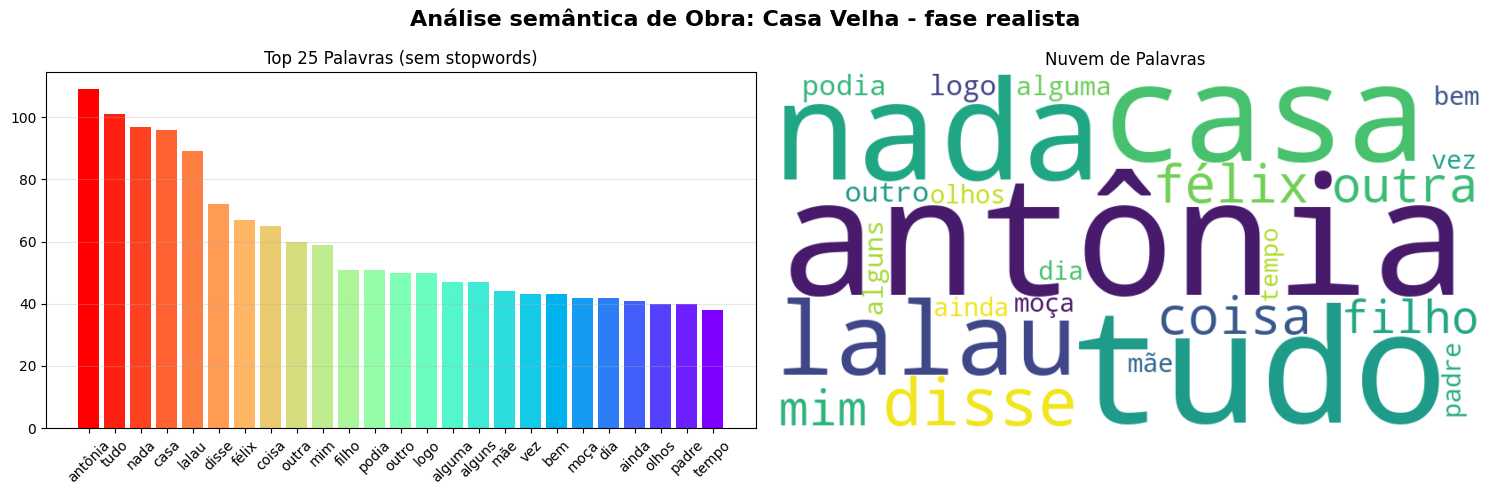

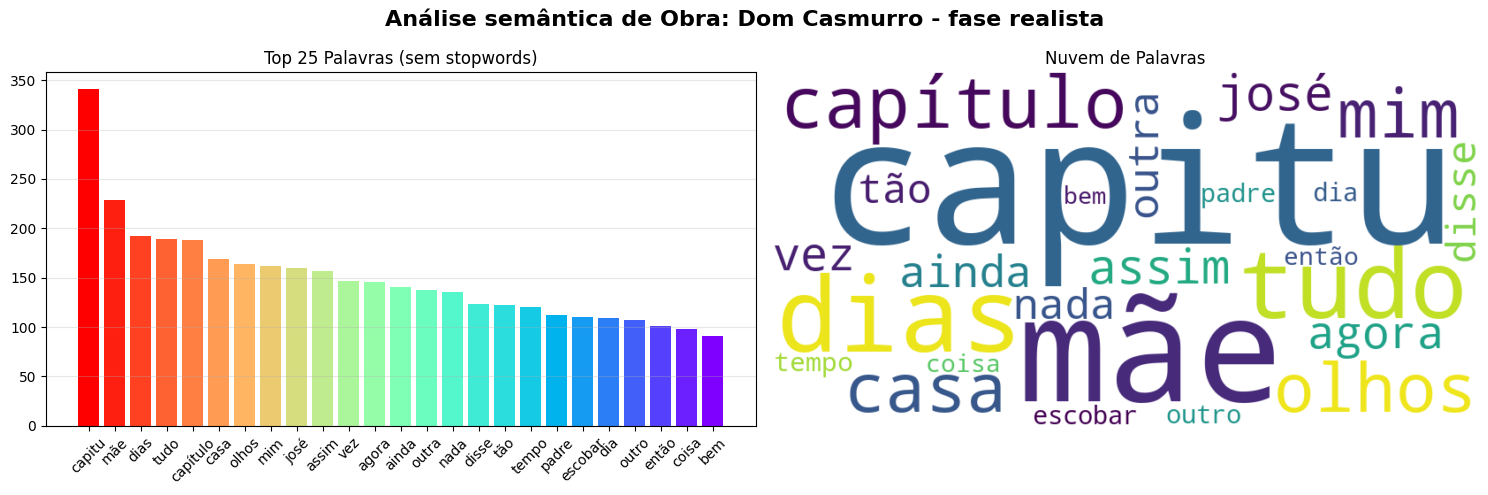

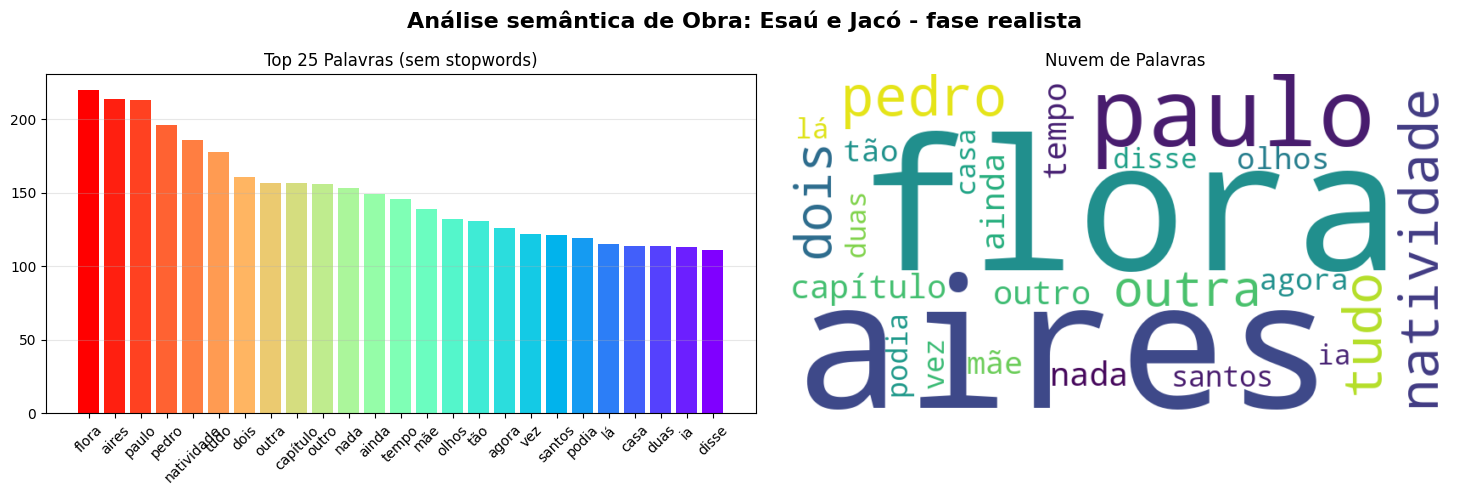

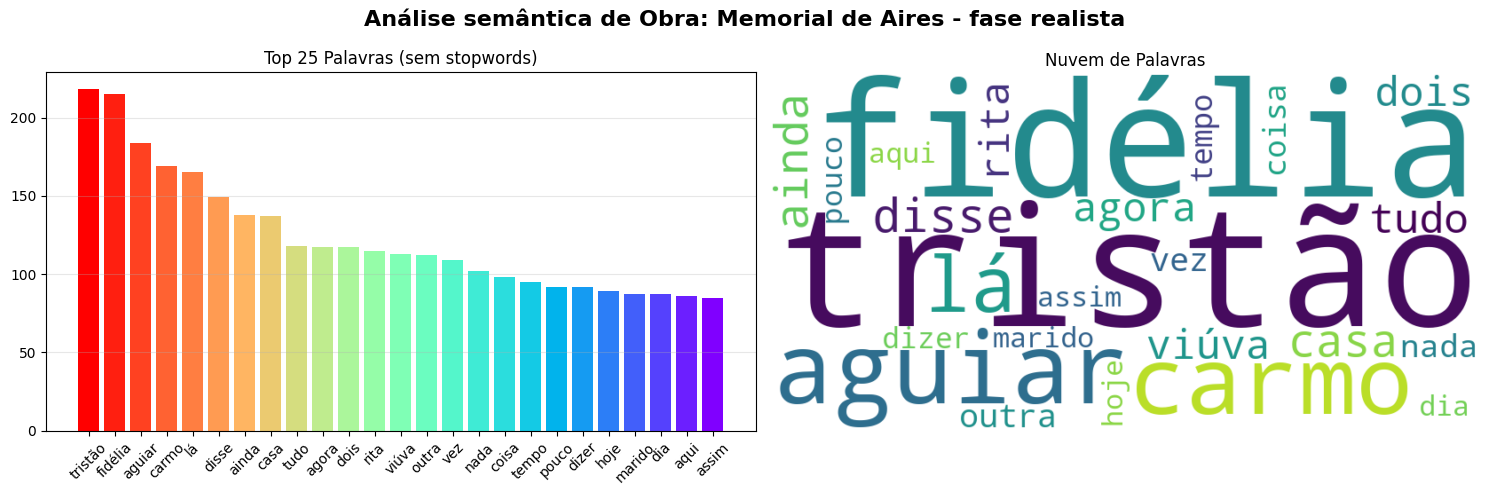

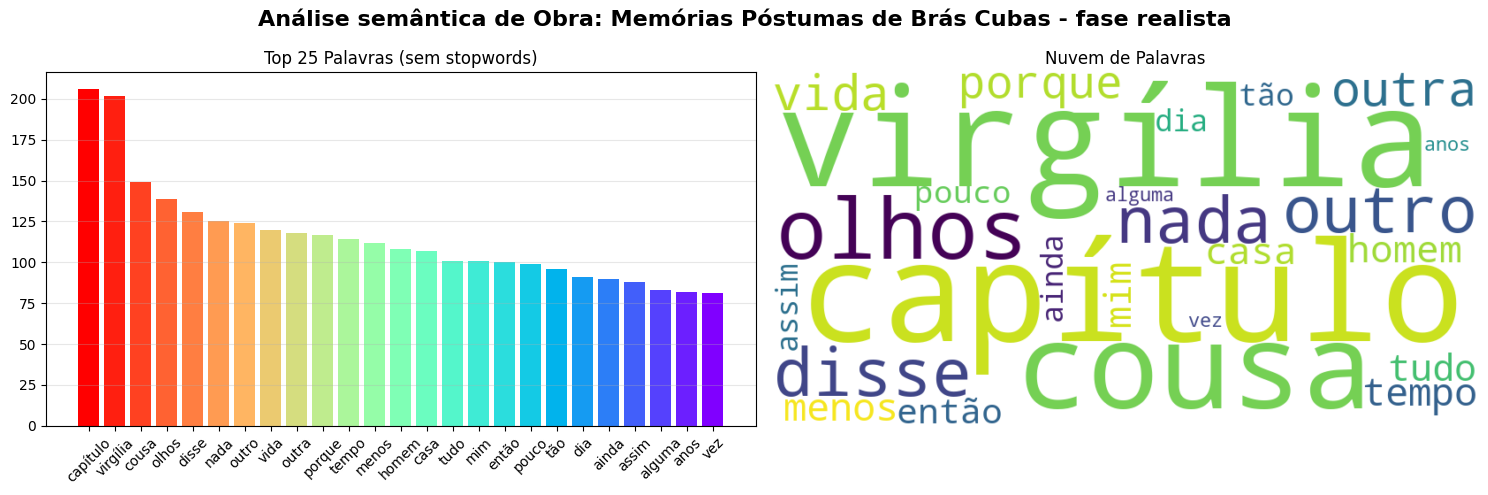

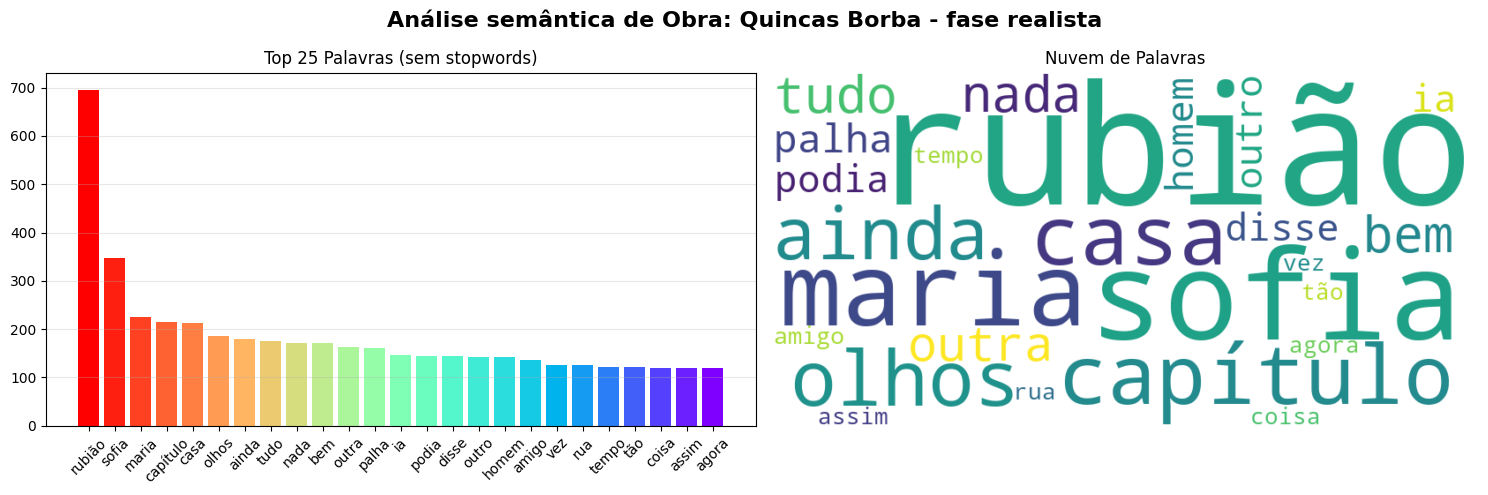

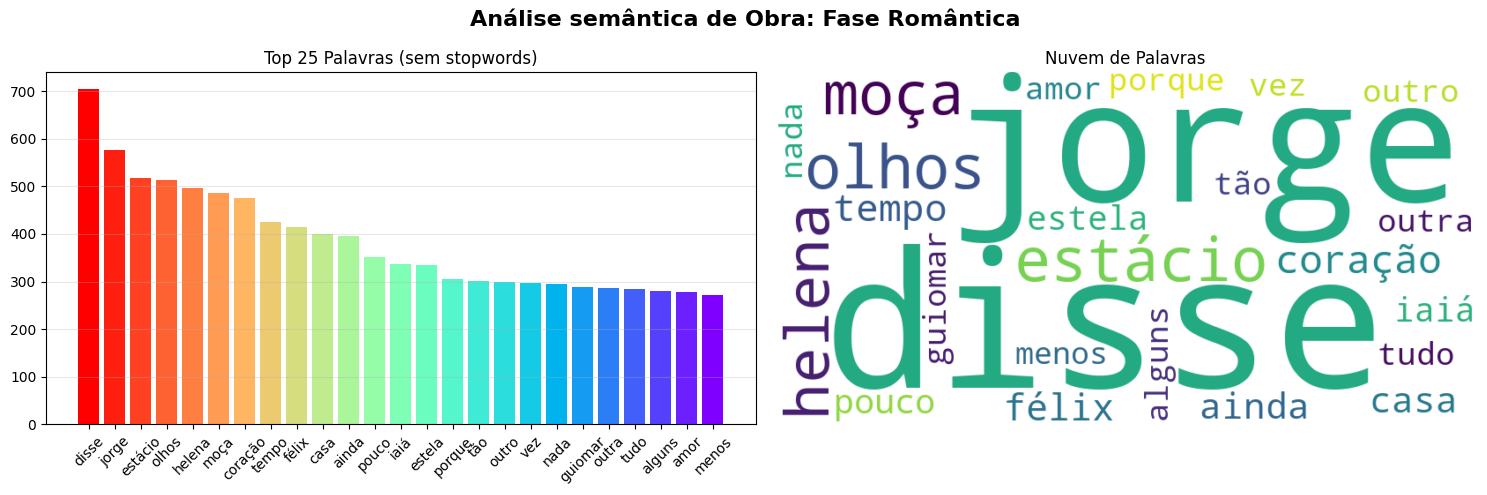

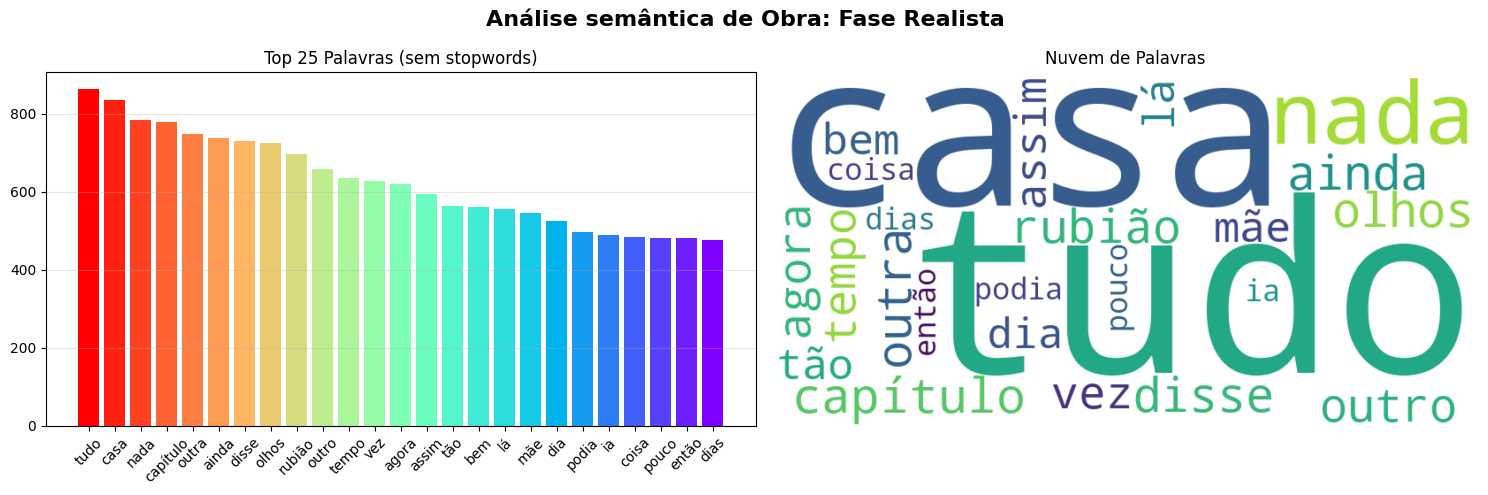

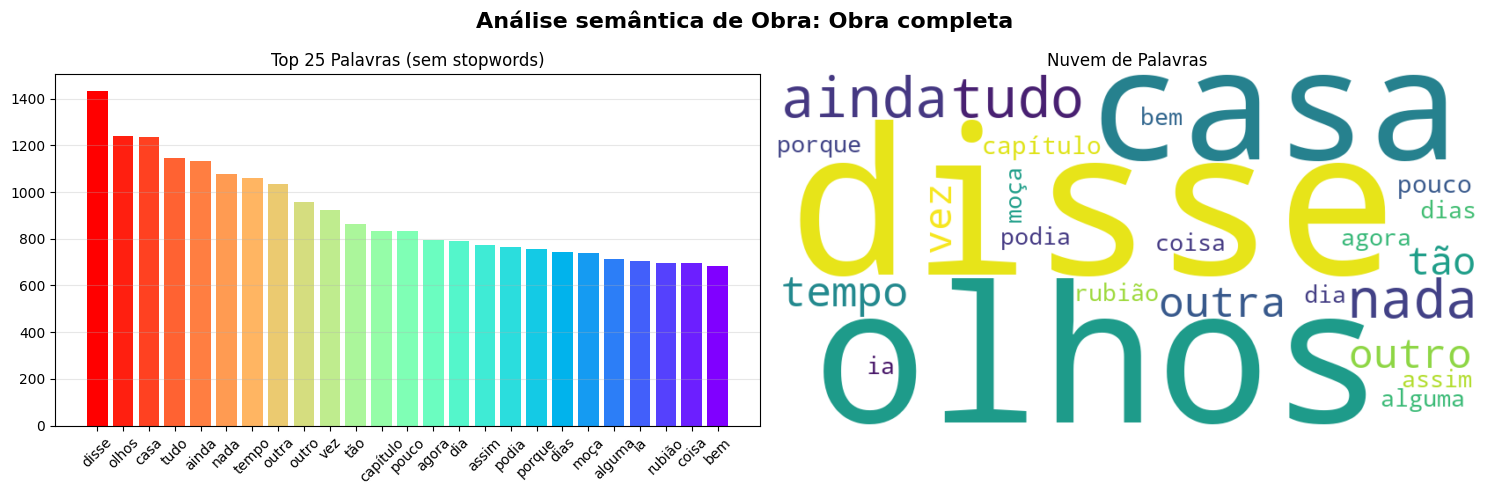

In [16]:
categorias = ['romântica', 'realista']

for fase in categorias:
    arquivos = glob.glob(f'obras/{fase}/*.txt')
    
    for arq in arquivos:
        nome_obra = os.path.basename(arq).replace('.txt', '')
        df = processar_obra2(arq)  # Processando e gerando gráfico individual
        gerar_graficos2(df, f"{nome_obra} - fase {fase}")
        
df_fase1 = processar_obra2('temp_fase_romântica.txt')
gerar_graficos2(df_fase1, f"Fase Romântica")
df_fase2 = processar_obra2('temp_fase_realista.txt')
gerar_graficos2(df_fase2, f"Fase Realista")
df_fase3 = processar_obra2('temp_obra_completa.txt')
gerar_graficos2(df_fase3, f"Obra completa")

# Resultados
Ao analisar os resultados das frequências das palavras nas obras após retirar as stopwords (conectivos), também é possível analisar um padrão de transição entre os romances. Na fase do romantismo, podemos notar uma concentração bem mais forte no nome dos principais personagens (Guiomar, Jorge, Estevão, Estácio, Helena, Félix, Lívia), enquanto na outra fase outras palavras possuem melhor distribuição. Além de que, na fase romântica há a presença de termos como "coração", "amor" e "moça", e indicadores de relações pessoais como "baronesa", "moço", "pai", típicos das dinâmicas sociais e amorosas dos seus primeiros romances.

Já na fase realista, as personagens femininas continuam centrais (Virgília, Capitu, Sofia, Fidélia), mas inseridas em contextos de análise psicológica e social mais densos. É possível observar uma maior ênfase em conceitos abstratos: "tudo", "nada", "vida", "homem", "cousa", "tempo". Além de que, surge a palavra "capítulo", indicando a grande quantidade de capítulos nessas obras, por exemplo, Memórias Póstumas possui 160 e Quincas Borba 201 capítulos, característica da escrita inovadora do autor no período.

Por fim, analisando toda obra de forma transversal, a presença constante de termos ligados à fala ("disse"), ao espaço doméstico da "casa" e, fundamentalmente, ao curioso motivo recorrente dos "olhos", revela uma literatura baseada na observação social e no diálogo, onde o olhar funciona como a principal ferramenta para desvendar a subjetividade humana ao longo de toda a sua trajetória literária.